In [1]:
import os
print(os.listdir("data"))

['archive']


In [2]:
print(os.listdir("data/archive"))

['city_day.csv', 'city_hour.csv', 'stations.csv', 'station_day.csv', 'station_hour.csv']


In [3]:
import pandas as pd

df = pd.read_csv("data/archive/city_day.csv")
print(df.shape)
print(df["Date"].min(), "to", df["Date"].max())

(18265, 16)


KeyError: 'Date'

In [4]:
import pandas as pd

df = pd.read_csv("data/archive/city_day.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(18265, 16)
['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [5]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

print("Date range:", df["Datetime"].min().date(), "to", df["Datetime"].max().date())
print("Cities:", df["City"].unique())
print(df["City"].value_counts())

Date range: 2015-01-01 to 2024-12-31
Cities: ['Delhi' 'Mumbai' 'Chennai' 'Kolkata' 'Bangalore']
City
Delhi        3653
Mumbai       3653
Chennai      3653
Kolkata      3653
Bangalore    3653
Name: count, dtype: int64


In [6]:
print(df.columns.tolist())
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False))
print("Duplicates:", df.duplicated().sum())

['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
City          0.0
Datetime      0.0
PM2.5         0.0
PM10          0.0
NO            0.0
NO2           0.0
NOx           0.0
NH3           0.0
CO            0.0
SO2           0.0
O3            0.0
Benzene       0.0
Toluene       0.0
Xylene        0.0
AQI           0.0
AQI_Bucket    0.0
dtype: float64
Duplicates: 0


In [7]:
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Month_Name"] = df["Datetime"].dt.month_name()

def get_season(month):
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Summer"
    if month in (6, 7, 8, 9):
        return "Monsoon"
    return "Post-monsoon"

df["Season"] = df["Month"].apply(get_season)

print(df["AQI"].describe())
df[["City", "Datetime", "AQI", "AQI_Bucket", "Year", "Month_Name", "Season"]].head()

count    18265.000000
mean       251.111382
std        144.502626
min          0.000000
25%        125.400000
50%        251.200000
75%        376.400000
max        500.000000
Name: AQI, dtype: float64


,City,Datetime,AQI,AQI_Bucket,Year,Month_Name,Season
0,Delhi,2015-01-01,204.5,Severe,2015,January,Winter
1,Mumbai,2015-01-01,60.9,Satisfactory,2015,January,Winter
2,Chennai,2015-01-01,486.5,Severe,2015,January,Winter
3,Kolkata,2015-01-01,174.4,Very Poor,2015,January,Winter
4,Bangalore,2015-01-01,489.7,Good,2015,January,Winter


In [8]:
print(df.groupby("City")["AQI"].mean().round(1))
print()
print(df.groupby("Season")["AQI"].mean().round(1))

City
Bangalore    249.8
Chennai      250.3
Delhi        251.5
Kolkata      250.6
Mumbai       253.3
Name: AQI, dtype: float64

Season
Monsoon         249.0
Post-monsoon    249.0
Summer          252.6
Winter          253.9
Name: AQI, dtype: float64


In [9]:
print(os.listdir("data/real"))

['city_day.csv', 'city_hour.csv', 'stations.csv', 'station_day.csv', 'station_hour.csv']


In [10]:
df = pd.read_csv("data/real/city_day.csv")

print(df.shape)
print(df.columns.tolist())
print()
print(df["Date"].min(), "to", df["Date"].max())
print("Cities:", df["City"].nunique())
print()
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False))

(29531, 16)
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

2015-01-01 to 2020-07-01
Cities: 26

Xylene        61.3
PM10          37.7
NH3           35.0
Toluene       27.2
Benzene       19.0
AQI           15.9
AQI_Bucket    15.9
PM2.5         15.6
NOx           14.2
O3            13.6
SO2           13.1
NO2           12.1
NO            12.1
CO             7.0
Date           0.0
City           0.0
dtype: float64


In [11]:
# Convert Date to a real date type
df["Date"] = pd.to_datetime(df["Date"])

# Drop rows with no AQI (we can't analyse those days)
before = len(df)
df = df.dropna(subset=["AQI"])
print("Dropped rows:", before - len(df))

# Drop duplicates, if any
df = df.drop_duplicates()

# New columns
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

def get_season(month):
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Summer"
    if month in (6, 7, 8, 9):
        return "Monsoon"
    return "Post-monsoon"

df["Season"] = df["Month"].apply(get_season)

# Now the same test that exposed the fake data
print()
print(df.groupby("City")["AQI"].mean().round(1).sort_values(ascending=False))
print()
print(df.groupby("Season")["AQI"].mean().round(1).sort_values(ascending=False))

Dropped rows: 4681

City
Ahmedabad             452.1
Delhi                 259.5
Patna                 240.8
Gurugram              225.1
Lucknow               218.0
Talcher               172.9
Jorapokhar            159.3
Brajrajnagar          150.3
Kolkata               140.6
Guwahati              140.1
Jaipur                133.7
Bhopal                132.8
Amritsar              119.9
Visakhapatnam         117.3
Chennai               114.5
Hyderabad             109.2
Mumbai                105.4
Kochi                 104.3
Chandigarh             96.5
Amaravati              95.3
Bengaluru              94.3
Ernakulam              92.4
Thiruvananthapuram     75.9
Coimbatore             73.0
Shillong               53.8
Aizawl                 34.8
Name: AQI, dtype: float64

Season
Winter          220.6
Post-monsoon    215.5
Summer          147.7
Monsoon         115.6
Name: AQI, dtype: float64


In [12]:
ahd = df[df["City"] == "Ahmedabad"]
print("Ahmedabad rows:", len(ahd))
print(ahd["Date"].min().date(), "to", ahd["Date"].max().date())
print()
print(ahd.groupby("Year")["AQI"].agg(["count", "mean"]).round(1))
print()
print(df.groupby("Season")["AQI"].mean().round(1).sort_values(ascending=False))

Ahmedabad rows: 1334
2015-01-29 to 2020-07-01

      count   mean
Year              
2015    263  311.0
2016    117  310.2
2017     69  558.8
2018    357  622.3
2019    352  516.4
2020    176  242.1

Season
Winter          220.6
Post-monsoon    215.5
Summer          147.7
Monsoon         115.6
Name: AQI, dtype: float64


In [13]:
print("Days with AQI above 500:", (df["AQI"] > 500).sum())
print("Max AQI:", df["AQI"].max())
print()
print(df[df["AQI"] > 500]["City"].value_counts())
print()
print(df[df["City"] == "Ahmedabad"][["CO", "PM2.5", "PM10", "AQI"]].describe().round(1))

Days with AQI above 500: 543
Max AQI: 2049.0

City
Ahmedabad     412
Delhi          48
Patna          25
Gurugram       22
Lucknow        15
Jorapokhar      7
Amritsar        4
Hyderabad       4
Talcher         4
Guwahati        2
Name: count, dtype: int64

           CO   PM2.5   PM10     AQI
count  1327.0  1332.0  397.0  1334.0
mean     22.2    67.9  112.8   452.1
std      21.3    39.4   38.8   311.7
min       0.1     3.0   11.5    48.0
25%       7.7    39.4   86.2   231.0
50%      16.3    58.4  107.7   384.5
75%      30.0    87.1  133.6   542.8
max     175.8   381.7  335.9  2049.0


In [14]:
# Compare median CO across cities
print(df.groupby("City")["CO"].median().round(1).sort_values(ascending=False).head(6))

# Clean version: drop Ahmedabad, cap remaining AQI at 500 (the scale maximum)
df_clean = df[df["City"] != "Ahmedabad"].copy()
df_clean["AQI"] = df_clean["AQI"].clip(upper=500)

print()
print("Rows before:", len(df), "| after:", len(df_clean))
print("Max AQI now:", df_clean["AQI"].max())
print()
print(df_clean.groupby("City")["AQI"].mean().round(1).sort_values(ascending=False).head(8))

City
Ahmedabad       16.3
Brajrajnagar     1.9
Talcher          1.8
Ernakulam        1.5
Patna            1.4
Lucknow          1.4
Name: CO, dtype: float64

Rows before: 24850 | after: 23516
Max AQI now: 500.0

City
Delhi           258.1
Patna           240.1
Gurugram        223.7
Lucknow         217.5
Talcher         172.7
Jorapokhar      158.7
Brajrajnagar    150.3
Kolkata         140.6
Name: AQI, dtype: float64


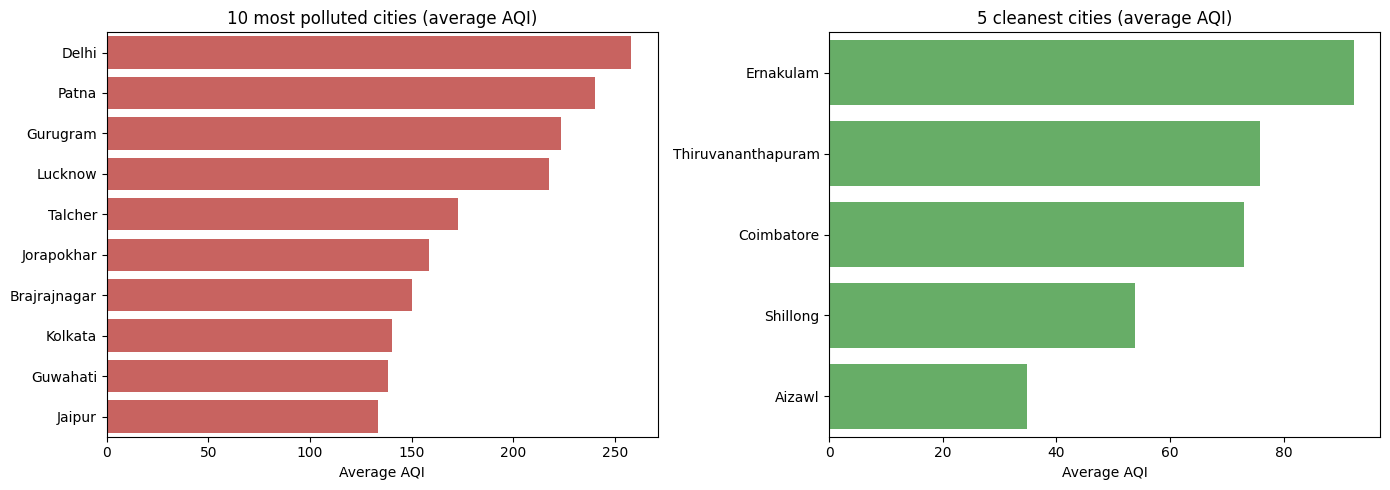

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

city_avg = df_clean.groupby("City")["AQI"].mean().sort_values(ascending=False)

top10 = city_avg.head(10)
bottom5 = city_avg.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top10.values, y=top10.index, ax=axes[0], color="#d9534f")
axes[0].set_title("10 most polluted cities (average AQI)")
axes[0].set_xlabel("Average AQI")
axes[0].set_ylabel("")

sns.barplot(x=bottom5.values, y=bottom5.index, ax=axes[1], color="#5cb85c")
axes[1].set_title("5 cleanest cities (average AQI)")
axes[1].set_xlabel("Average AQI")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("aqi_city_ranking.png", dpi=150)
plt.show()

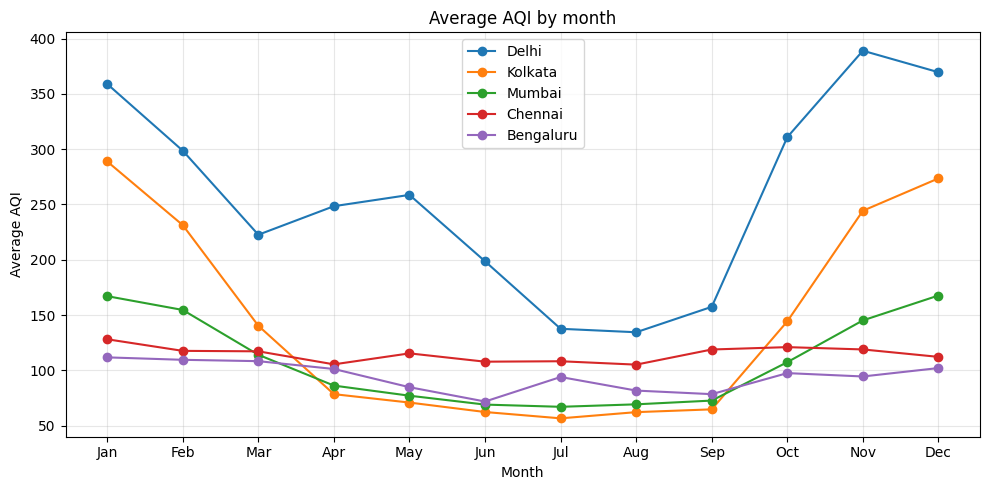

In [16]:
cities = ["Delhi", "Kolkata", "Mumbai", "Chennai", "Bengaluru"]
monthly = df_clean.groupby(["Month", "City"])["AQI"].mean().reset_index()

plt.figure(figsize=(10, 5))
for c in cities:
    sub = monthly[monthly["City"] == c]
    plt.plot(sub["Month"], sub["AQI"], marker="o", label=c)

plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.title("Average AQI by month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("aqi_monthly_trend.png", dpi=150)
plt.show()

Year                 2019   2020  Change_%
City                                      
Lucknow             189.8  107.6     -43.3
Delhi               217.9  129.3     -40.6
Amaravati            83.0   50.5     -39.1
Gurugram            211.5  130.4     -38.3
Visakhapatnam       107.2   67.4     -37.1
Bengaluru           100.1   65.7     -34.4
Kolkata              82.4   56.6     -31.3
Hyderabad            91.2   64.0     -29.9
Jaipur              137.8   98.0     -28.8
Amritsar            110.5   80.7     -26.9
Mumbai               86.0   63.9     -25.7
Patna               153.1  117.6     -23.2
Thiruvananthapuram   67.7   52.8     -22.0
Chennai             101.3   81.7     -19.3
Coimbatore           66.5   56.2     -15.5
Guwahati             87.2   74.1     -15.1
Talcher             125.1  108.5     -13.3
Brajrajnagar        133.9  132.5      -1.1
Jorapokhar          123.9  131.2       5.9


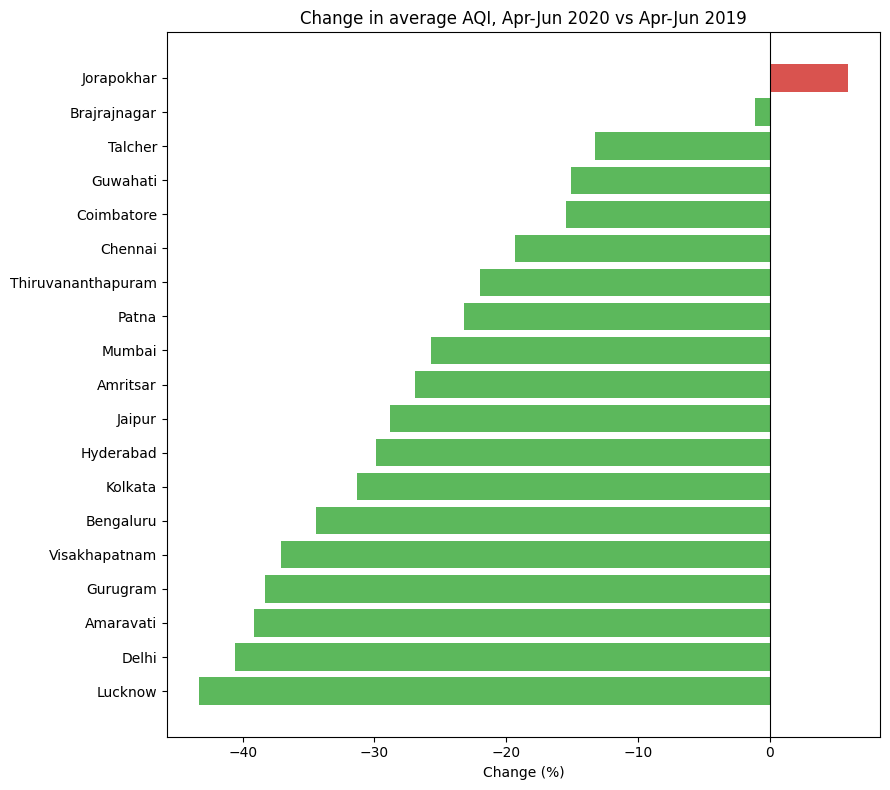

In [17]:
lock = df_clean[(df_clean["Month"].between(4, 6)) & (df_clean["Year"].isin([2019, 2020]))]

pivot = lock.groupby(["City", "Year"])["AQI"].mean().unstack().dropna()
pivot["Change_%"] = ((pivot[2020] - pivot[2019]) / pivot[2019] * 100).round(1)
pivot = pivot.sort_values("Change_%")
print(pivot.round(1))

plt.figure(figsize=(9, 8))
colors = ["#5cb85c" if x < 0 else "#d9534f" for x in pivot["Change_%"]]
plt.barh(pivot.index, pivot["Change_%"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Change in average AQI, Apr-Jun 2020 vs Apr-Jun 2019")
plt.xlabel("Change (%)")
plt.tight_layout()
plt.savefig("aqi_lockdown_change.png", dpi=150)
plt.show()

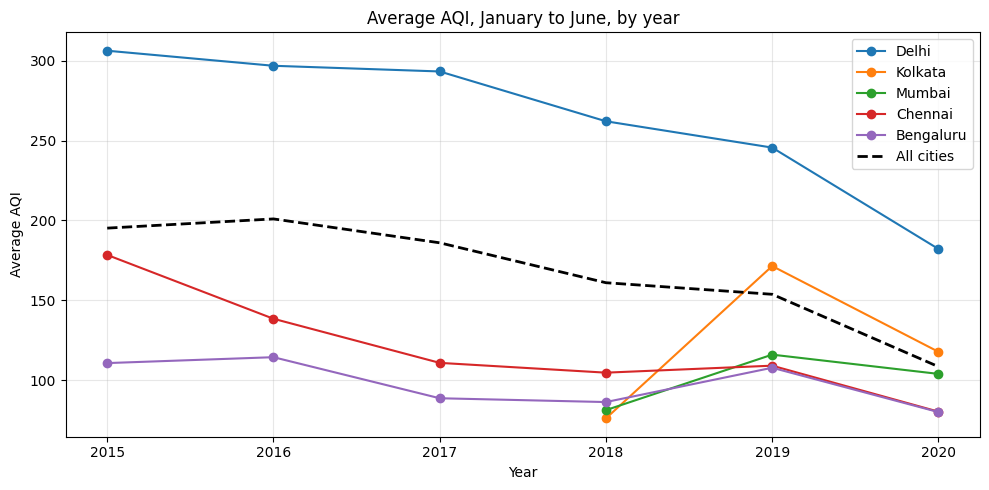

In [18]:
h1 = df_clean[df_clean["Month"] <= 6]
yearly = h1.groupby(["Year", "City"])["AQI"].mean().reset_index()

cities = ["Delhi", "Kolkata", "Mumbai", "Chennai", "Bengaluru"]

plt.figure(figsize=(10, 5))
for c in cities:
    sub = yearly[yearly["City"] == c]
    plt.plot(sub["Year"], sub["AQI"], marker="o", label=c)

overall = h1.groupby("Year")["AQI"].mean()
plt.plot(overall.index, overall.values, color="black", linestyle="--", linewidth=2, label="All cities")

plt.title("Average AQI, January to June, by year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("aqi_yearly_trend.png", dpi=150)
plt.show()

PM10       0.90
PM2.5      0.88
NOx        0.50
NO         0.49
NO2        0.45
CO         0.30
NH3        0.25
SO2        0.25
O3         0.23
Toluene    0.14
Xylene     0.10
Benzene    0.01
Name: AQI, dtype: float64


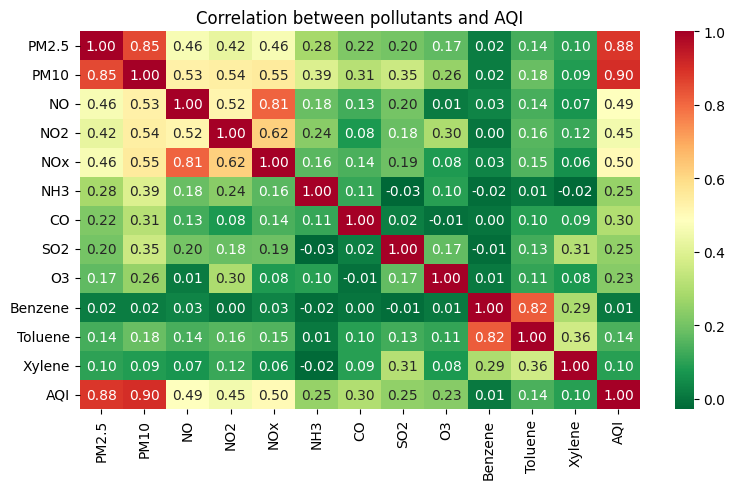

In [19]:
pollutants = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3",
              "Benzene", "Toluene", "Xylene"]

corr = df_clean[pollutants + ["AQI"]].corr()["AQI"].drop("AQI").sort_values(ascending=False)
print(corr.round(2))

plt.figure(figsize=(8, 5))
sns.heatmap(df_clean[pollutants + ["AQI"]].corr(), annot=True, fmt=".2f", cmap="RdYlGn_r")
plt.title("Correlation between pollutants and AQI")
plt.tight_layout()
plt.savefig("aqi_pollutant_correlation.png", dpi=150)
plt.show()

                    PM2.5  PM10   NO2   SO2    CO    O3 Top_driver
Aizawl               0.95  0.94  0.21 -0.18  0.74  0.54      PM2.5
Amaravati            0.91  0.89  0.74  0.24  0.20  0.45      PM2.5
Amritsar             0.69  0.85  0.23  0.02  0.44 -0.02       PM10
Bengaluru            0.43  0.60  0.23  0.03  0.38  0.26       PM10
Bhopal               0.90  0.85  0.69  0.28  0.68  0.19      PM2.5
Brajrajnagar         0.89  0.82  0.71  0.39  0.49 -0.00      PM2.5
Chandigarh           0.92  0.88  0.13 -0.12  0.64 -0.23      PM2.5
Chennai              0.69  0.37  0.20  0.09  0.35  0.17      PM2.5
Coimbatore           0.37  0.32 -0.06  0.30  0.37  0.45         O3
Delhi                0.86  0.88  0.66  0.42  0.29  0.33       PM10
Ernakulam            0.34  0.33  0.13 -0.10  0.48   NaN         CO
Gurugram             0.83  0.86  0.16  0.08  0.29 -0.12       PM10
Guwahati             0.87  0.87  0.46  0.07  0.78 -0.05      PM2.5
Hyderabad            0.77  0.68  0.12  0.22  0.38  0.30      P

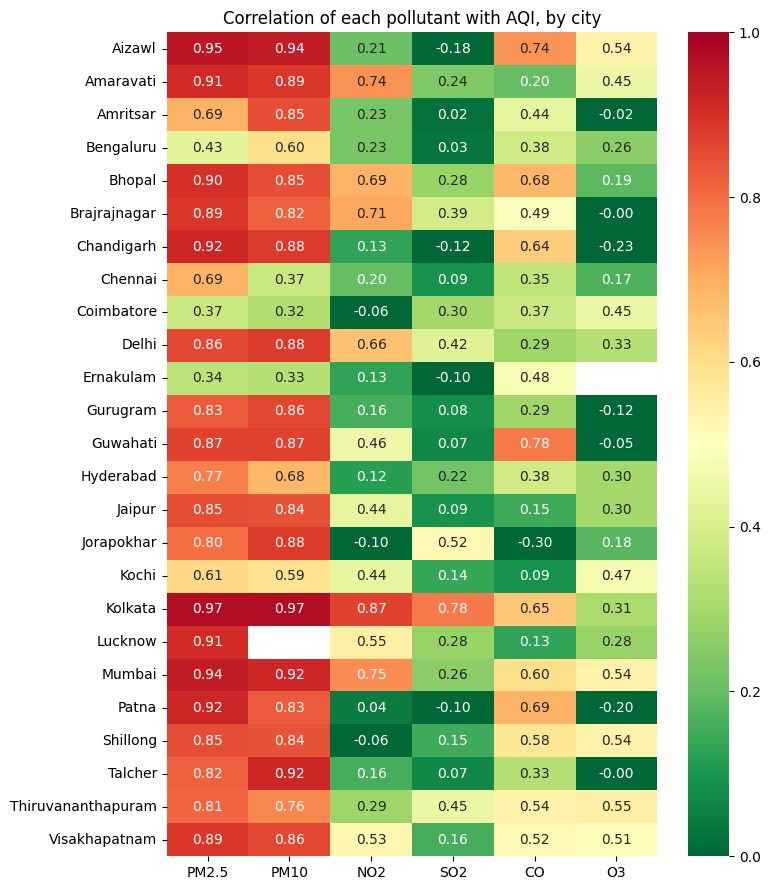

In [20]:
cols = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

rows = {city: g[cols].corrwith(g["AQI"]) for city, g in df_clean.groupby("City")}
by_city = pd.DataFrame(rows).T.round(2)
by_city["Top_driver"] = by_city[cols].idxmax(axis=1)
print(by_city)

plt.figure(figsize=(8, 9))
sns.heatmap(by_city[cols], annot=True, fmt=".2f", cmap="RdYlGn_r", vmin=0, vmax=1)
plt.title("Correlation of each pollutant with AQI, by city")
plt.tight_layout()
plt.savefig("aqi_drivers_by_city.png", dpi=150)
plt.show()

AQI_Category        Good  Satisfactory  Moderate  Poor  Very Poor  Severe  \
City                                                                        
Delhi                1.1           7.9      26.0  27.1       26.0    12.0   
Patna                0.0          11.7      34.7  16.2       25.4    11.9   
Gurugram             1.4          15.5      31.2  21.3       24.0     6.5   
Lucknow              0.8          19.3      30.5  18.6       25.0     5.8   
Talcher              2.7          21.5      46.4  12.0       13.9     3.4   
Guwahati            23.4          27.3      22.4  13.9       11.9     1.0   
Kolkata             15.8          37.8      20.2  15.8        8.8     1.7   
Jorapokhar           1.3          17.8      58.5  15.7        4.4     2.3   
Brajrajnagar         2.0          17.1      59.0  16.8        5.0     0.0   
Bhopal               0.7          27.3      59.4  11.2        1.4     0.0   
Jaipur               0.4          29.0      59.5  10.1        0.9     0.2   

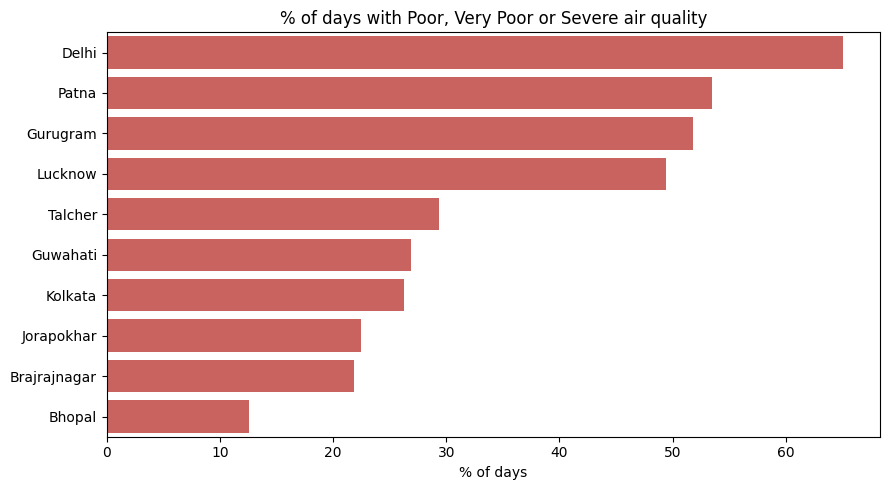

In [21]:
bins = [0, 50, 100, 200, 300, 400, 500]
labels = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
df_clean["AQI_Category"] = pd.cut(df_clean["AQI"], bins=bins, labels=labels, include_lowest=True)

share = pd.crosstab(df_clean["City"], df_clean["AQI_Category"], normalize="index") * 100
share["Poor_or_worse_%"] = share[["Poor", "Very Poor", "Severe"]].sum(axis=1)
share["Days_of_data"] = df_clean.groupby("City").size()
share = share.sort_values("Poor_or_worse_%", ascending=False)
print(share.round(1))

top = share.head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top["Poor_or_worse_%"], y=top.index, color="#d9534f")
plt.title("% of days with Poor, Very Poor or Severe air quality")
plt.xlabel("% of days")
plt.ylabel("")
plt.tight_layout()
plt.savefig("aqi_poor_days.png", dpi=150)
plt.show()